# Display a map of google

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow
import pandas as pd
import osmnx as ox

In [2]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("../limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")

roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

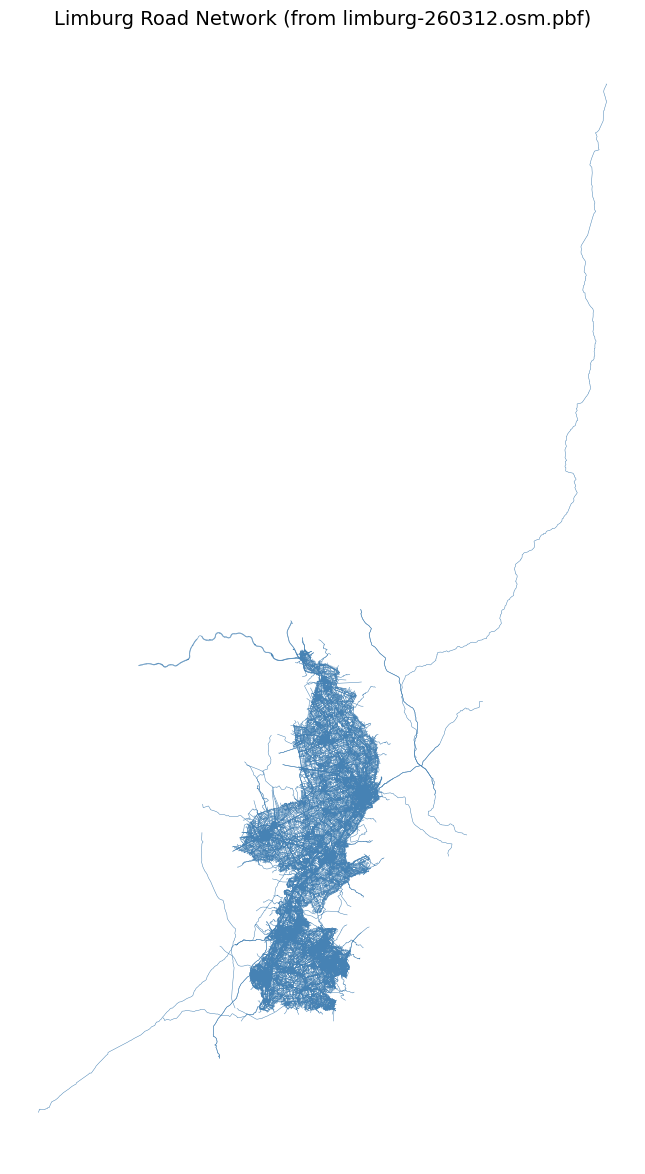

In [3]:
fig, ax = plt.subplots(figsize=(12, 12))
roads.plot(ax=ax, linewidth=0.35, color="steelblue")
ax.set_title("Limburg Road Network (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

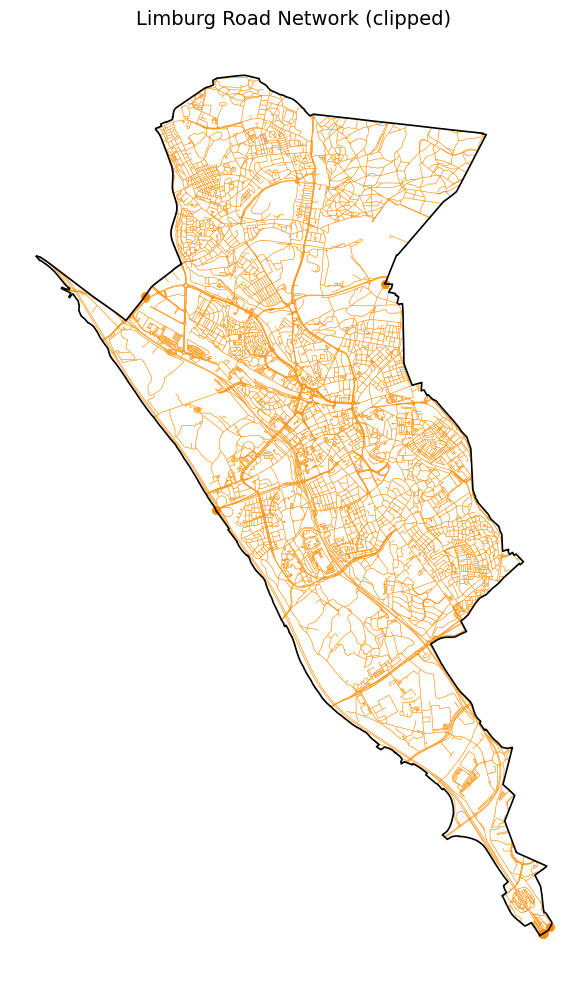

Road segments after clipping: 10,181


In [4]:
# Build Limburg boundary and clip roads to it
limburg_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands")
limburg_boundary = limburg_boundary.to_crs(roads.crs)
limburg_geom = limburg_boundary.union_all()

# Keep road-like lines and cut segments at the Limburg border
if "highway" in roads.columns:
    roads_for_plot = roads[roads["highway"].notna()].copy()
else:
    roads_for_plot = roads.copy()

roads_limburg = gpd.clip(roads_for_plot, limburg_geom)
roads_limburg = roads_limburg[roads_limburg.geometry.notna() & ~roads_limburg.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
roads_limburg.plot(ax=ax, linewidth=0.45, color="darkorange")
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("Limburg Road Network (clipped)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Road segments after clipping: {len(roads_limburg):,}")

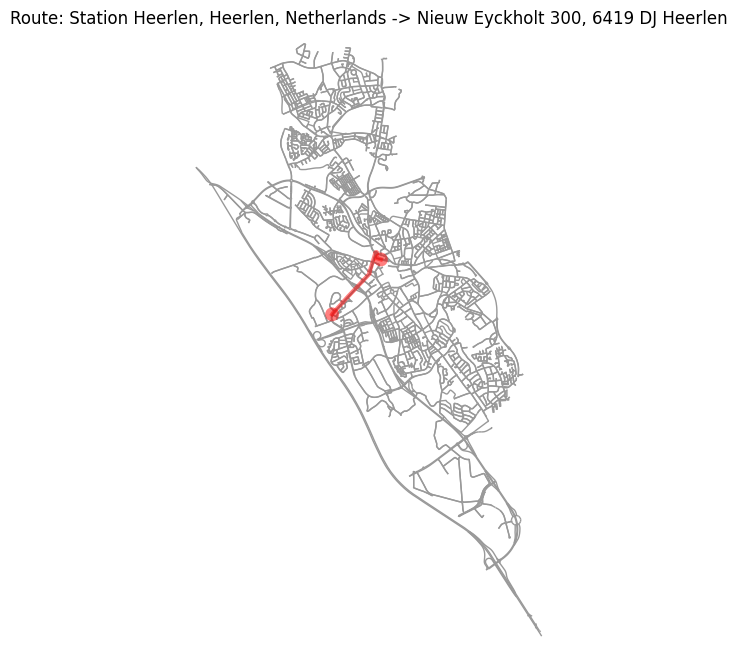

In [5]:
# Set your route endpoints here
start_point = "Station Heerlen, Heerlen, Netherlands"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

In [7]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("../limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")



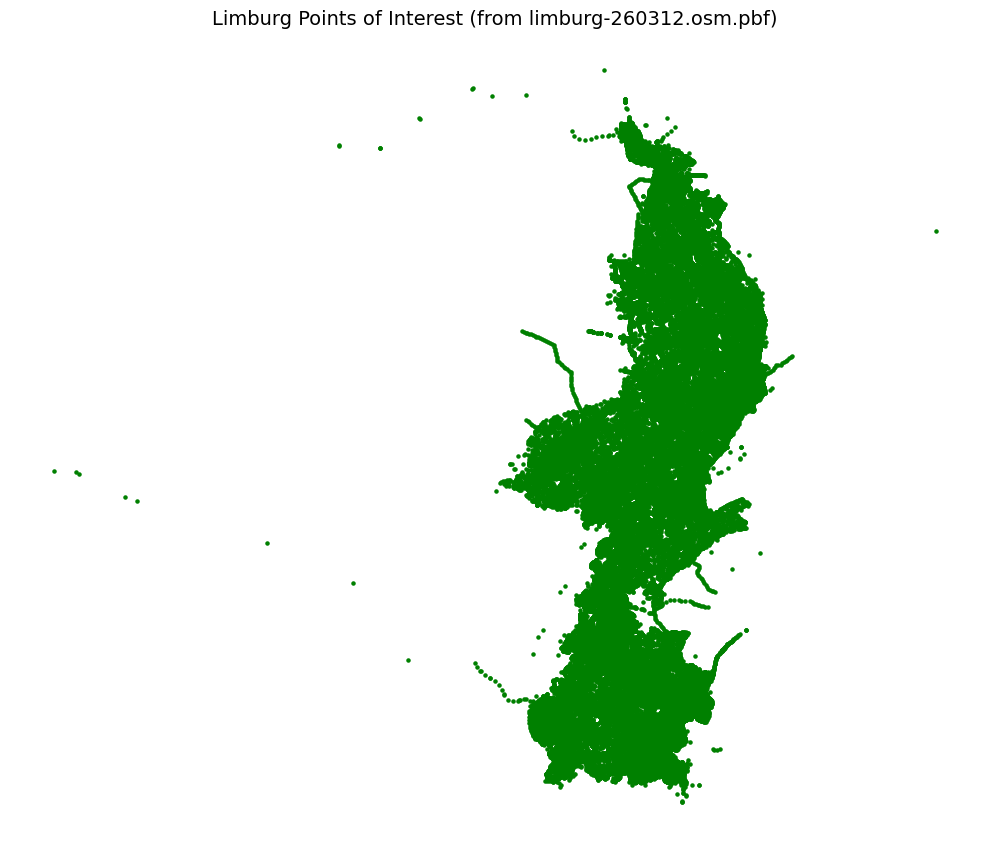

In [8]:
points = gpd.read_file(pbf_path, layer="points")

# Project for cleaner plotting in meters
points = points.to_crs(epsg=3857)

points.plot(figsize=(10, 10), color="green", markersize=5)
plt.title("Limburg Points of Interest (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

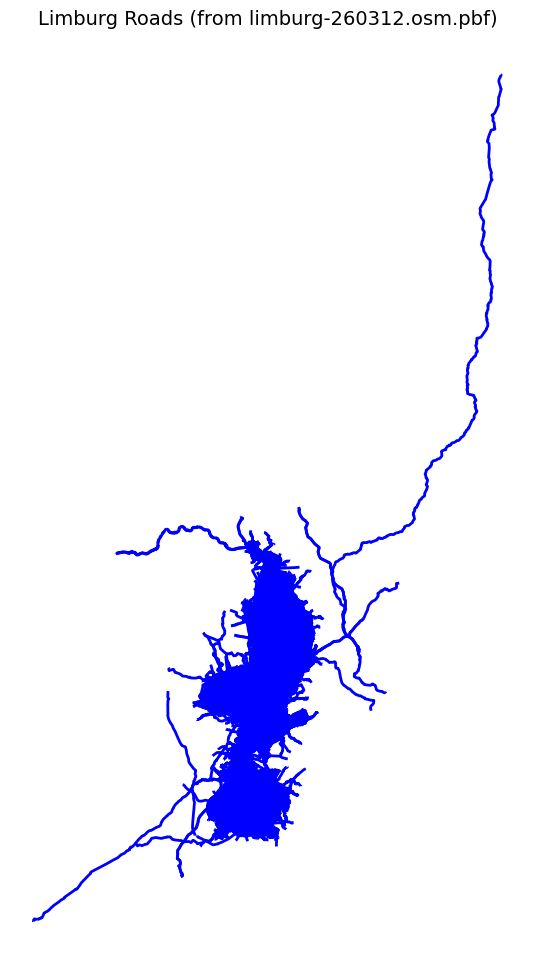

In [9]:
roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

roads.plot(figsize=(10, 10), color="blue", linewidth=2)
plt.title("Limburg Roads (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,geometry
0,4443691,NaN,footway,NaN,NaN,NaN,NaN,NaN,0,"""surface""=>""paving_stones""","LINESTRING (670006.311 6578139.577, 670003.951..."


In [11]:
desired_columns = [
    "osm_id", "name", "highway", "waterway", "aerialway", 
    "barrier", "man_made", "railway", "z_order", "other_tags"
]

roads = gpd.read_file(
    pbf_path, 
    layer="lines", 
    engine="pyogrio",
    columns=desired_columns,
    use_arrow=False
)
# Instead of using other_tags maxspeed, check if the speed_limit column is not null

roads_with_speed = roads[roads['other_tags'].str.contains('maxspeed', na=False)].copy()
roads_with_speed['speed_limit'] = roads_with_speed['other_tags'].str.extract(r'"maxspeed"=>"(\d+)"')

roads_with_speed = roads_with_speed[desired_columns + ['speed_limit', 'geometry']].copy()

In [12]:
roads_with_speed.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
14,4578867,Von-Byland-Straße,residential,NaN,NaN,NaN,NaN,NaN,3,"""lane_markings""=>""no"",""maxspeed""=>""30"",""zone:m...",30,"LINESTRING (5.87941 51.02503, 5.87947 51.025, ..."


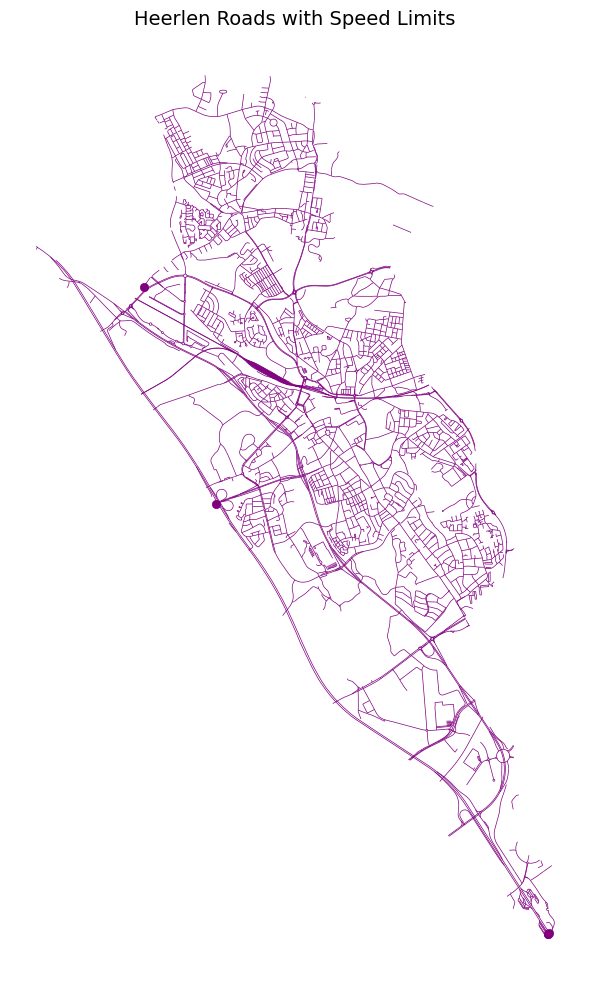

In [13]:
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
ax.set_title("Heerlen Roads with Speed Limits", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [14]:
roads_heerlen.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


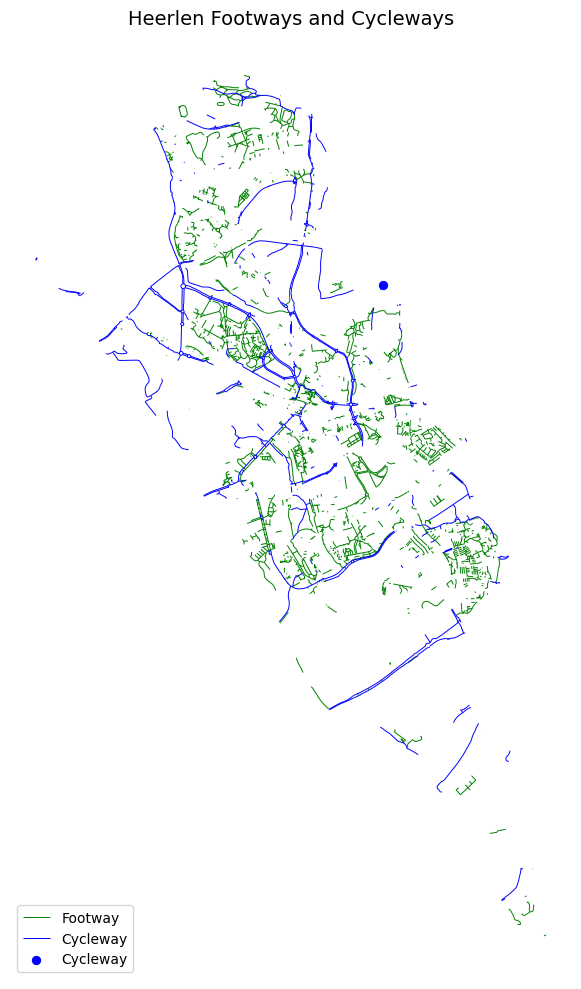

In [15]:
# Add cycleways and footways in Heerlen: footways green, cycleways blue

footway_roads = roads[roads['highway'] == 'footway'].copy()
footway_roads = footway_roads[footway_roads.geometry.notna() & ~footway_roads.geometry.is_empty].copy()

cycleway_roads = roads[roads['highway'] == 'cycleway'].copy()
cycleway_roads = cycleway_roads[cycleway_roads.geometry.notna() & ~cycleway_roads.geometry.is_empty].copy()

heerlen_geom = heerlen_boundary.geometry.iloc[0]
footway_heerlen = gpd.clip(footway_roads, heerlen_geom)
cycleway_heerlen = gpd.clip(cycleway_roads, heerlen_geom)

fig, ax = plt.subplots(figsize=(10, 10))
footway_heerlen.plot(ax=ax, linewidth=0.7, color="green", label="Footway")
cycleway_heerlen.plot(ax=ax, linewidth=0.7, color="blue", label="Cycleway")
ax.set_title("Heerlen Footways and Cycleways", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [16]:
# load in this csv clients.csv
clients = pd.read_csv("../output/clients.csv")

addresses = clients["address"].copy()
addresses.head(3)

0    Bethlehemstraat 24, 6418 Heerlen
1        Trompstraat 30, 6412 Heerlen
2     Nazarethstraat 40, 6418 Heerlen
Name: address, dtype: str

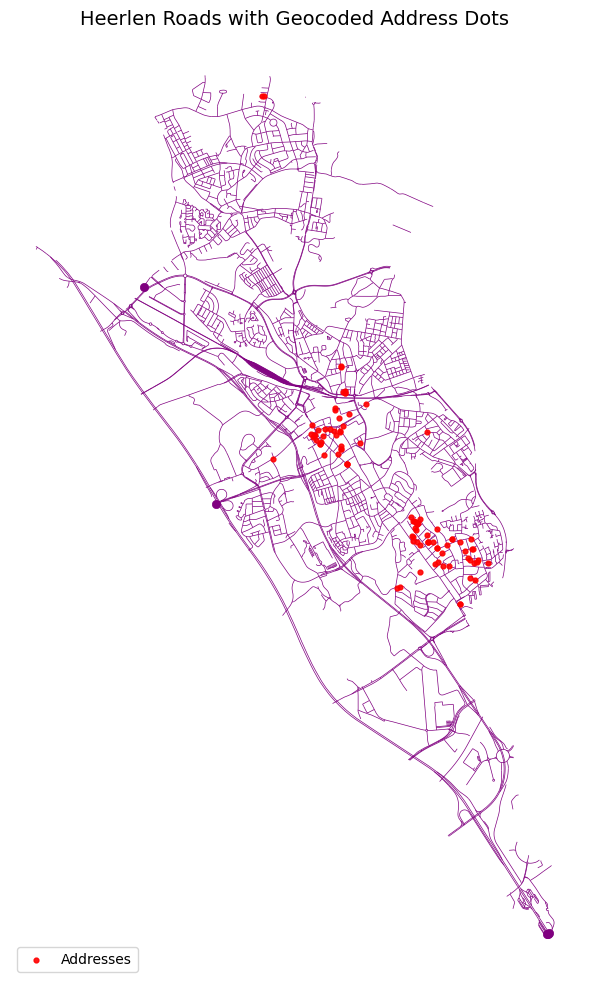

Addresses in clients.csv: 100
Geocoded successfully: 90
Failed geocoding: 10
Points inside Heerlen after clipping: 90


In [17]:
# Plot Heerlen roads and geocoded client addresses as dots
clients = pd.read_csv("../output/clients.csv")

def geocode_address(address: str):
    query = address if "netherlands" in address.lower() else f"{address}, Heerlen, Netherlands"
    try:
        lat, lon = ox.geocode(query)
        return pd.Series({"latitude": lat, "longitude": lon, "geocode_ok": True})
    except Exception:
        return pd.Series({"latitude": None, "longitude": None, "geocode_ok": False})

geocoded = clients["address"].apply(geocode_address)
clients_geocoded = pd.concat([clients, geocoded], axis=1)
clients_geocoded_ok = clients_geocoded[clients_geocoded["geocode_ok"]].copy()

address_points = gpd.GeoDataFrame(
    clients_geocoded_ok,
    geometry=gpd.points_from_xy(clients_geocoded_ok["longitude"], clients_geocoded_ok["latitude"]),
    crs="EPSG:4326",
)

heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

address_points = address_points.to_crs(roads_with_speed.crs)
address_points_heerlen = gpd.clip(address_points, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
address_points_heerlen.plot(
    ax=ax,
    color="red",
    markersize=12,
    alpha=0.9,
    zorder=3,
    label="Addresses",
)

ax.set_title("Heerlen Roads with Geocoded Address Dots", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Addresses in clients.csv: {len(clients)}")
print(f"Geocoded successfully: {len(clients_geocoded_ok)}")
print(f"Failed geocoding: {len(clients) - len(clients_geocoded_ok)}")
print(f"Points inside Heerlen after clipping: {len(address_points_heerlen)}")

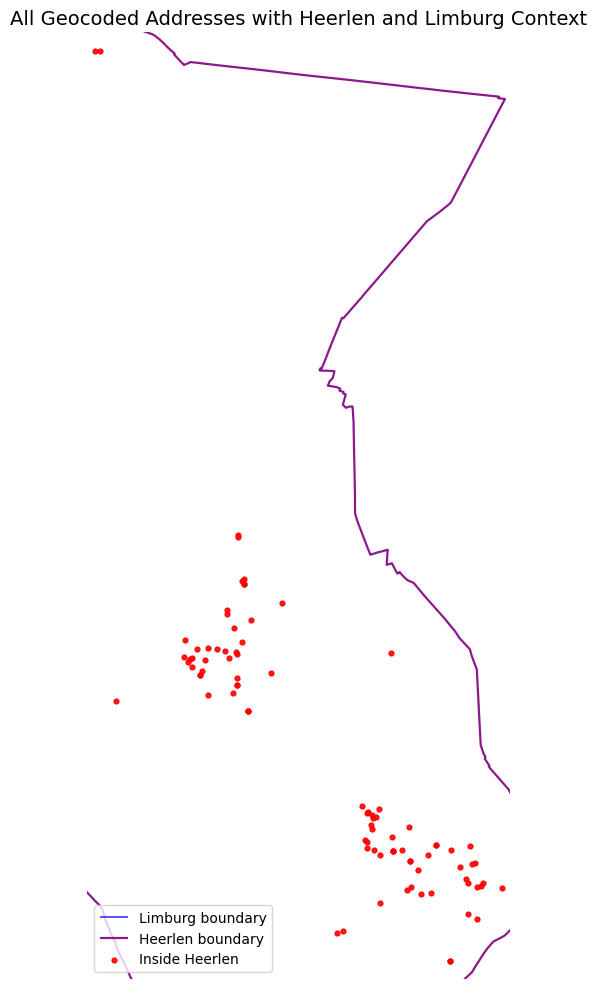

Total points: 90
Inside Heerlen: 90
Outside Heerlen: 0


In [18]:
# Show all geocoded dots with Heerlen and surrounding Limburg context

# Build Limburg province boundary in the same CRS used for plotting
limburg_boundary = ox.geocode_to_gdf("Limburg, Netherlands").to_crs(heerlen_boundary.crs)

# Split points by whether they are inside Heerlen
address_points_inside = address_points[address_points.geometry.within(heerlen_boundary.geometry.iloc[0])].copy()
address_points_outside = address_points[~address_points.geometry.within(heerlen_boundary.geometry.iloc[0])].copy()

fig, ax = plt.subplots(figsize=(10, 10))

# Context boundaries
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="blue", alpha=0.8, zorder=1, label="Limburg boundary")
heerlen_boundary.boundary.plot(ax=ax, linewidth=1.6, color="purple", alpha=0.9, zorder=2, label="Heerlen boundary")

# Plot all dots
if not address_points_inside.empty:
    address_points_inside.plot(
        ax=ax,
        color="red",
        markersize=12,
        alpha=0.9,
        zorder=3,
        label="Inside Heerlen",
    )

if not address_points_outside.empty:
    address_points_outside.plot(
        ax=ax,
        color="orange",
        markersize=14,
        alpha=0.95,
        zorder=4,
        label="Outside Heerlen",
    )

# Zoom to all dots (inside + outside) with tiny padding
if not address_points.empty:
    minx, miny, maxx, maxy = address_points.total_bounds
    width = max(maxx - minx, 1e-6)
    height = max(maxy - miny, 1e-6)
    pad_x = width * 0.02
    pad_y = height * 0.02
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_autoscale_on(False)

ax.set_title("All Geocoded Addresses with Heerlen and Limburg Context", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Total points: {len(address_points)}")
print(f"Inside Heerlen: {len(address_points_inside)}")
print(f"Outside Heerlen: {len(address_points_outside)}")

In [19]:
# give the list of outside heerlen
outside_addresses = address_points_outside[["address", "latitude", "longitude"]].copy()
print("Addresses outside Heerlen:")
print(outside_addresses.to_string(index=False))

Addresses outside Heerlen:
Empty DataFrame
Columns: [address, latitude, longitude]
Index: []


In [20]:
roads_heerlen.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


In [21]:
temp_roads = roads_heerlen[roads_heerlen['name'].isin(['Nieuw-Eyckholt', 'Gelein'])].copy()

In [22]:
temp_roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
19810,6748264,Gelein,living_street,NaN,NaN,NaN,NaN,NaN,0,"""cycleway:both""=>""no"",""lit""=>""yes"",""maxspeed""=...",15,"LINESTRING (5.96406 50.88285, 5.96468 50.88325..."


C:\Users\merli\AppData\Local\Temp\ipykernel_32144\2212790073.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(road_names), 1))


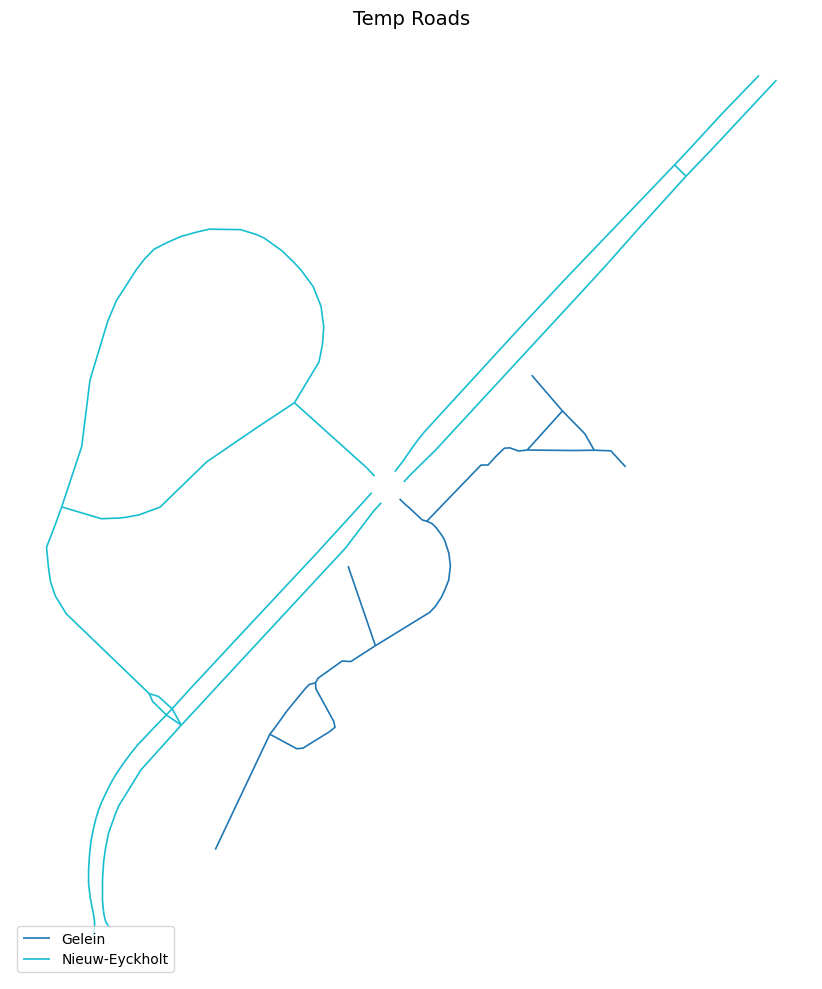

In [23]:
# Colour each different road name with a different colour, and add a legend

fig, ax = plt.subplots(figsize=(10, 10))

road_names = temp_roads['name'].dropna().unique()
cmap = plt.cm.get_cmap('tab10', max(len(road_names), 1))

for idx, road_name in enumerate(road_names):
    temp_roads[temp_roads['name'] == road_name].plot(
        ax=ax,
        linewidth=1.2,
        color=cmap(idx),
        label=road_name,
    )

ax.set_title("Temp Roads", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [24]:
# Do not let the same name road cross itself

for i, road1 in temp_roads.iterrows():
    for j, road2 in temp_roads.iterrows():
        if i >= j:
            continue
        if road1.geometry.intersects(road2.geometry):
            print(f"{road1['name']} intersects with {road2['name']}")


            

Gelein intersects with Gelein
Gelein intersects with Gelein
Gelein intersects with Gelein
Gelein intersects with Gelein
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-Eyckholt intersects with Nieuw-Eyckholt
Nieuw-

In [25]:
# display all road names in roads_heerlen within the bounding area of temp_roads
minx, miny, maxx, maxy = temp_roads.total_bounds
roads_in_temp_area = roads_heerlen.cx[minx:maxx, miny:maxy].copy()

roads_in_temp_area





,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
20030,6748703,Willem Schweitzerlaan,residential,NaN,NaN,NaN,NaN,NaN,3,"""lit""=>""yes"",""maxspeed""=>""30"",""surface""=>""asph...",30,"LINESTRING (5.96675 50.8791, 5.96606 50.87972,..."
19873,6748385,Valkenburgerweg,tertiary,NaN,NaN,NaN,NaN,NaN,4,"""cycleway:both""=>""lane"",""cycleway:both:lane""=>...",50,"LINESTRING (5.96358 50.88055, 5.96637 50.88159..."
19823,6748290,NaN,service,NaN,NaN,NaN,NaN,NaN,0,"""maxspeed""=>""50""",50,"LINESTRING (5.96689 50.88181, 5.96649 50.88253)"
19810,6748264,Gelein,living_street,NaN,NaN,NaN,NaN,NaN,0,"""cycleway:both""=>""no"",""lit""=>""yes"",""maxspeed""=...",15,"LINESTRING (5.96406 50.88285, 5.96468 50.88325..."
19843,6748321,Gelein,living_street,NaN,NaN,NaN,NaN,NaN,0,"""cycleway:both""=>""no"",""lit""=>""yes"",""maxspeed""=...",15,"LINESTRING (5.96598 50.88336, 5.96587 50.88348..."
...,...,...,...,...,...,...,...,...,...,...,...,...
163688,942663475,Nieuw-Eyckholt,secondary,NaN,NaN,NaN,NaN,NaN,6,"""bicycle""=>""use_sidepath"",""lit""=>""yes"",""maxspe...",50,"LINESTRING (5.96342 50.88306, 5.96334 50.88299..."
139200,699620704,Gelein,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""bicycle""=>""use_sidepath"",""lane_markings""=>""no...",15,"LINESTRING (5.96383 50.88296, 5.96374 50.88301)"
74621,199543215,NaN,secondary,NaN,NaN,NaN,NaN,NaN,6,"""bicycle""=>""use_sidepath"",""foot""=>""use_sidepat...",50,"LINESTRING (5.96342 50.88306, 5.96344 50.88303..."
20239,6749171,NaN,secondary,NaN,NaN,NaN,NaN,NaN,6,"""bicycle""=>""use_sidepath"",""foot""=>""use_sidepat...",50,"LINESTRING (5.96353 50.88298, 5.96359 50.88297..."


C:\Users\merli\AppData\Local\Temp\ipykernel_32144\715761633.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(names), 1))


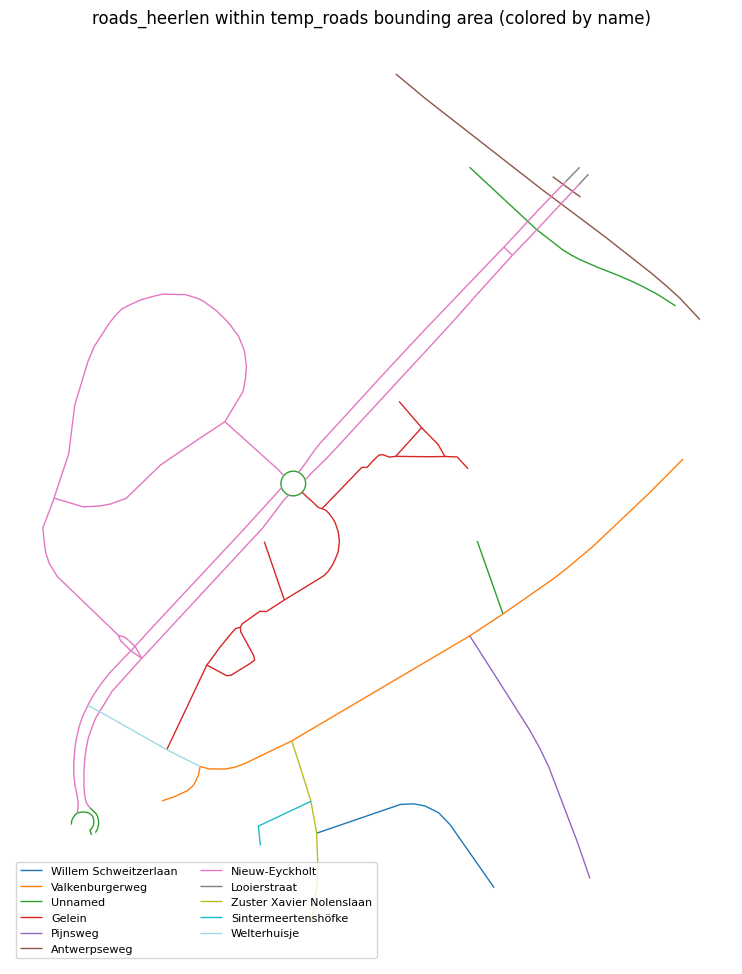

In [26]:
# # Roads in the bounding box of temp_roads
minx, miny, maxx, maxy = temp_roads.total_bounds
roads_in_temp_area = roads_heerlen.cx[minx:maxx, miny:maxy].copy()

# Keep valid geometries and create a label for unnamed roads
roads_in_temp_area = roads_in_temp_area[
    roads_in_temp_area.geometry.notna() & ~roads_in_temp_area.geometry.is_empty
].copy()
roads_in_temp_area["name_plot"] = roads_in_temp_area["name"].fillna("Unnamed")

# Plot with one color per road name
fig, ax = plt.subplots(figsize=(10, 10))
names = roads_in_temp_area["name_plot"].unique()
cmap = plt.cm.get_cmap("tab20", max(len(names), 1))

for k, n in enumerate(names):
    roads_in_temp_area[roads_in_temp_area["name_plot"] == n].plot(
        ax=ax,
        color=cmap(k),
        linewidth=1.0,
        label=n
    )

ax.set_title("roads_heerlen within temp_roads bounding area (colored by name)", fontsize=12)
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


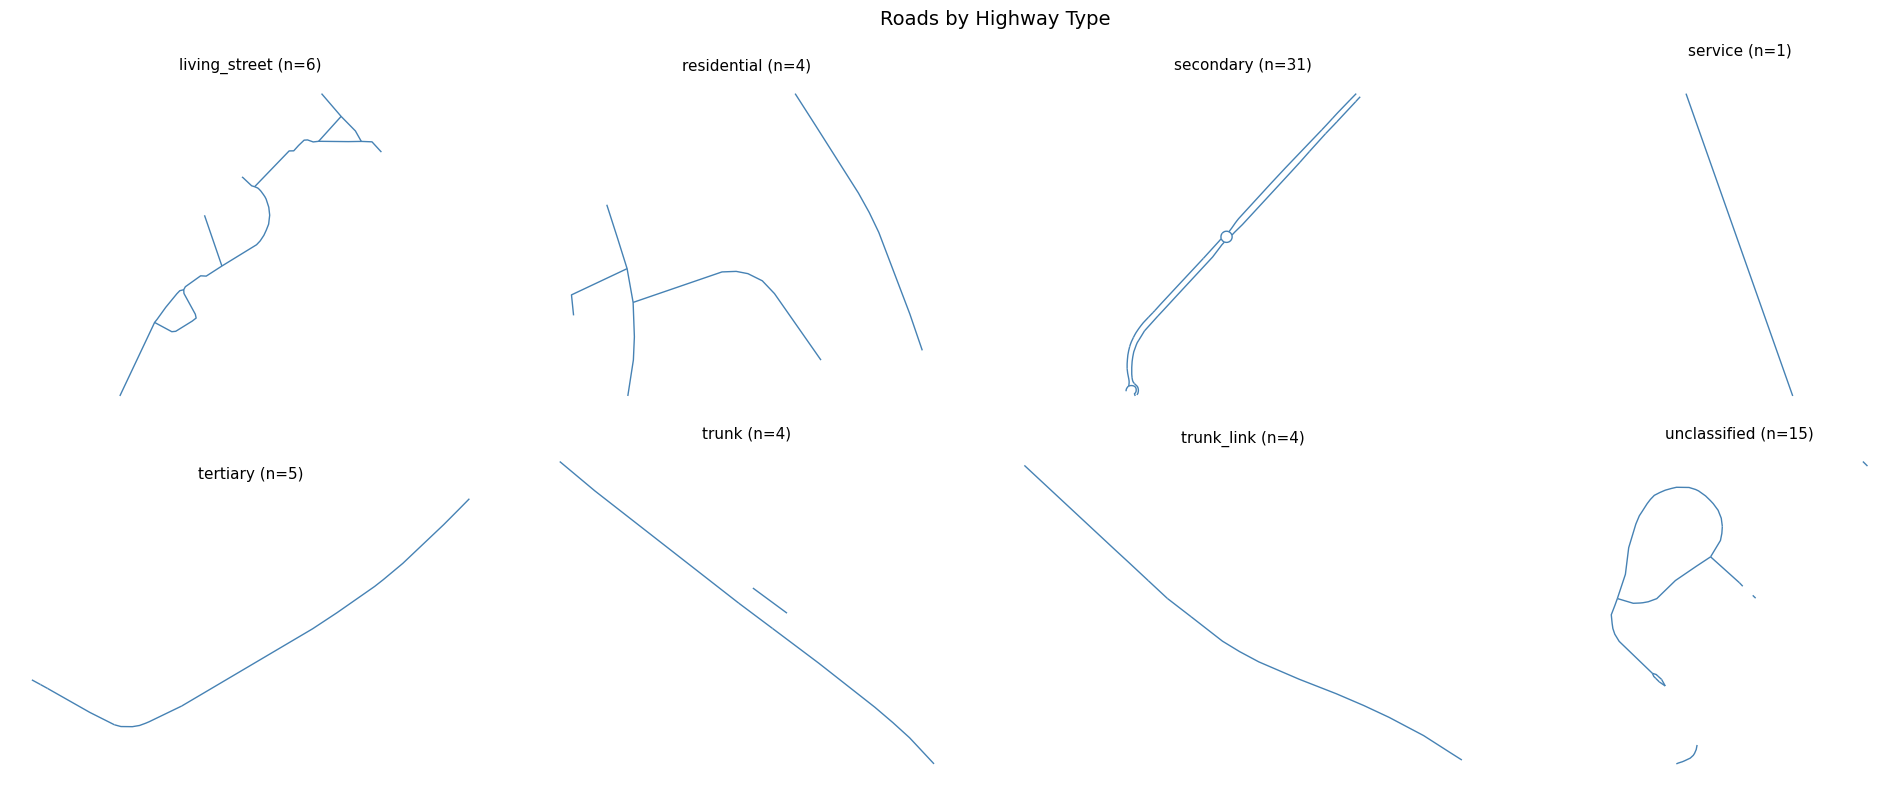

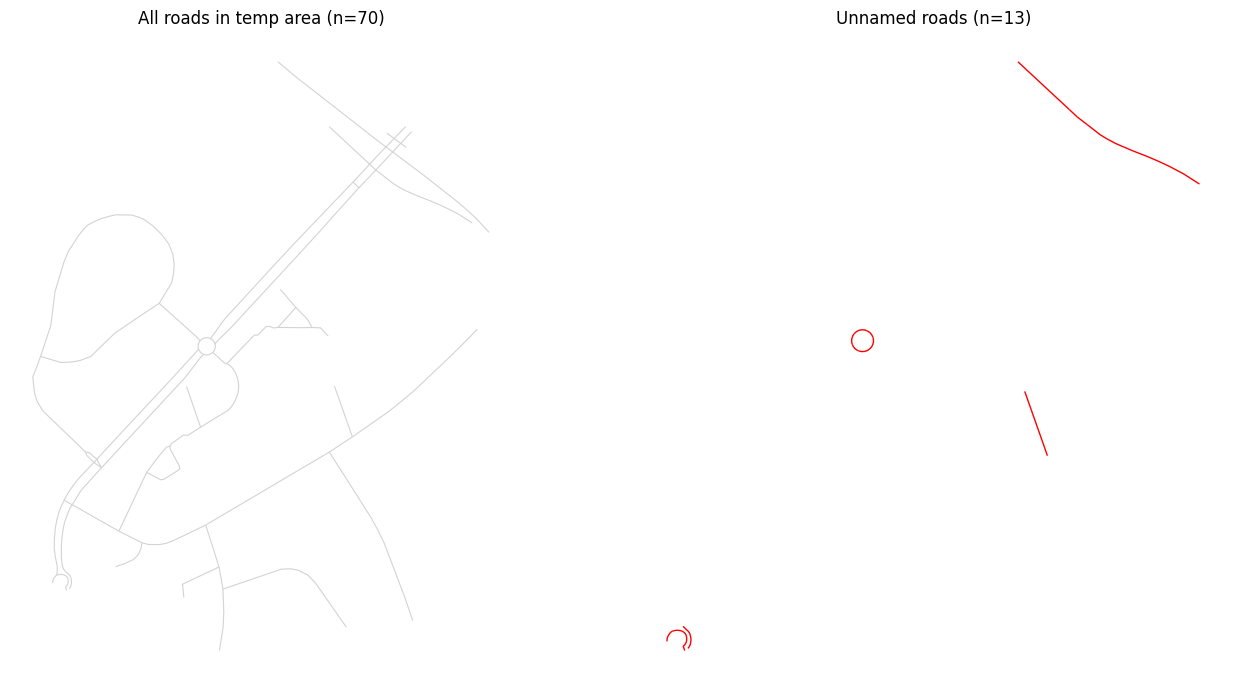

Total unnamed roads displayed: 13
    osm_id name    highway waterway aerialway barrier man_made railway  z_order                                                                                                                                                                                                                                                     other_tags speed_limit                                                                                                                                                                                                                                                                                                                                       geometry name_plot highway_plot
   6748290  NaN    service      NaN       NaN     NaN      NaN     NaN        0                                                                                                                                                                                      

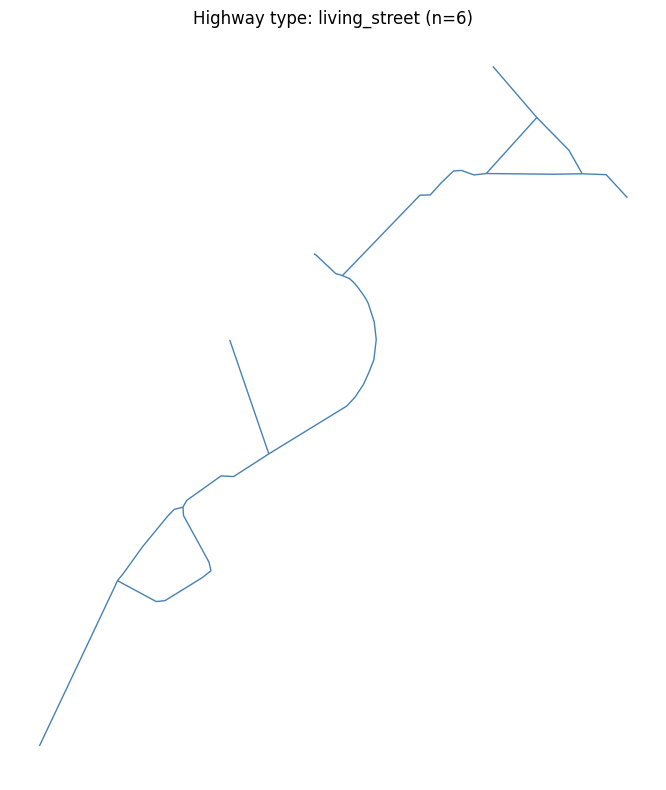

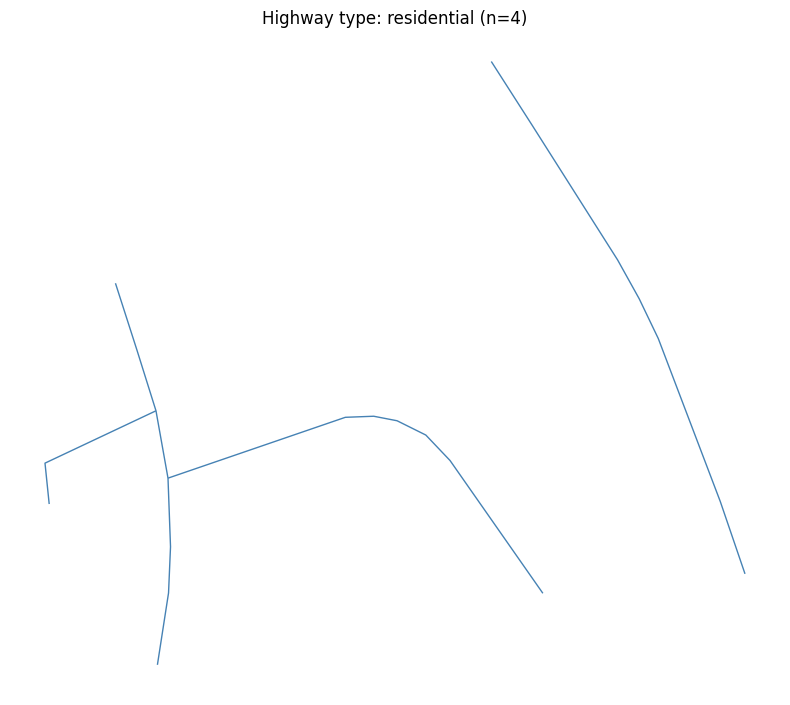

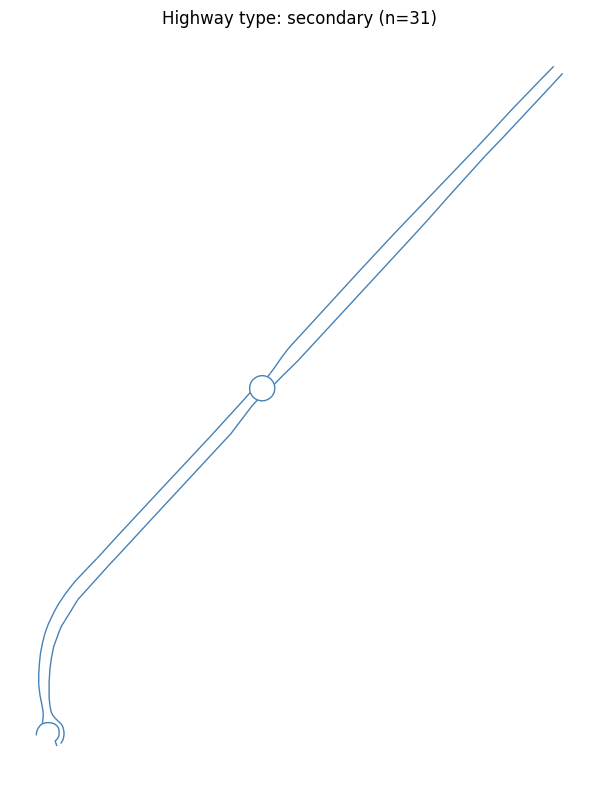

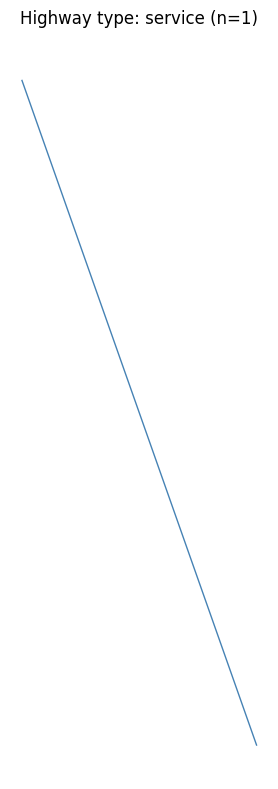

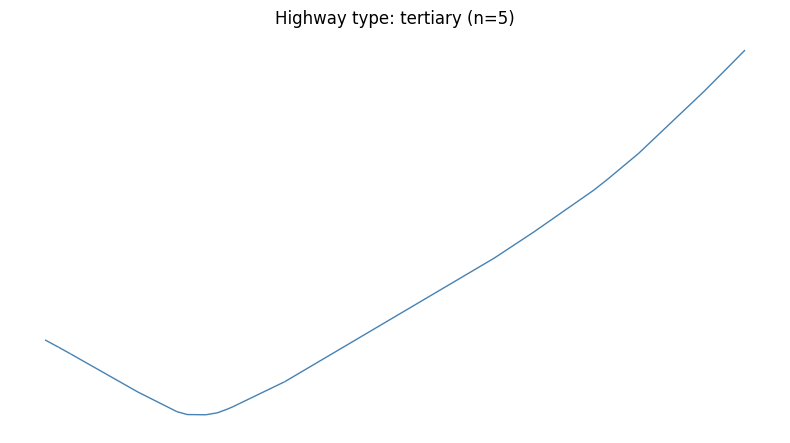

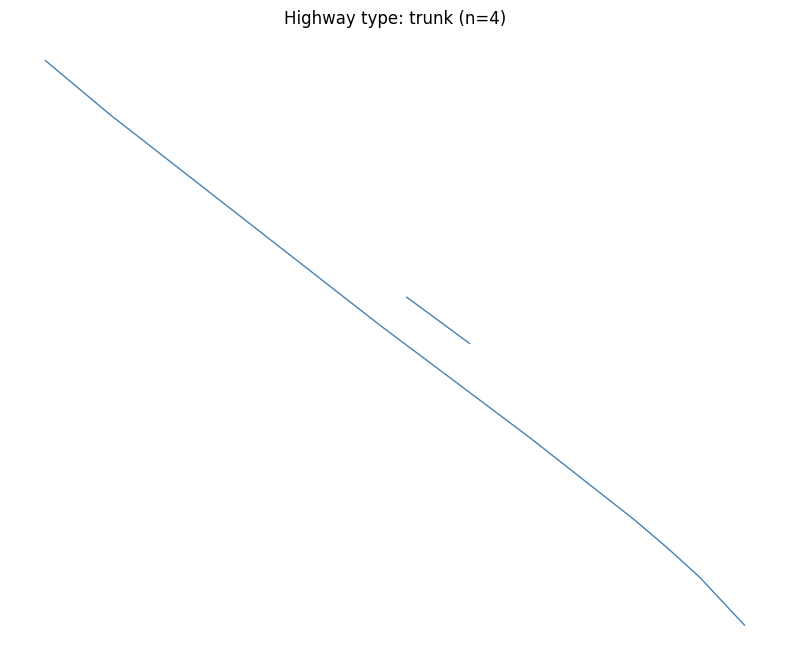

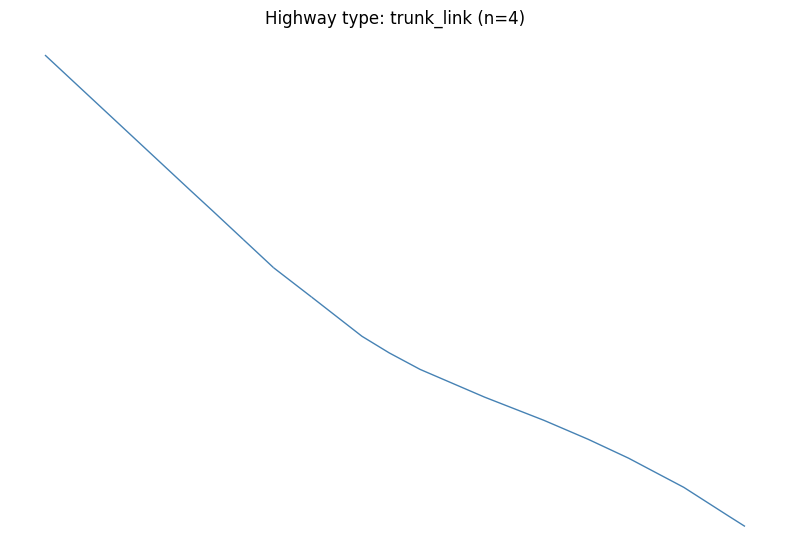

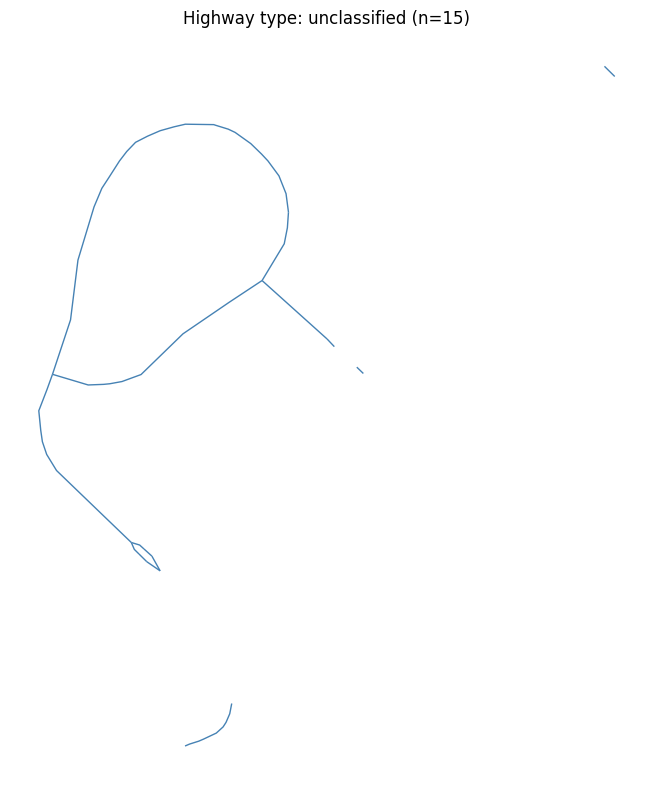

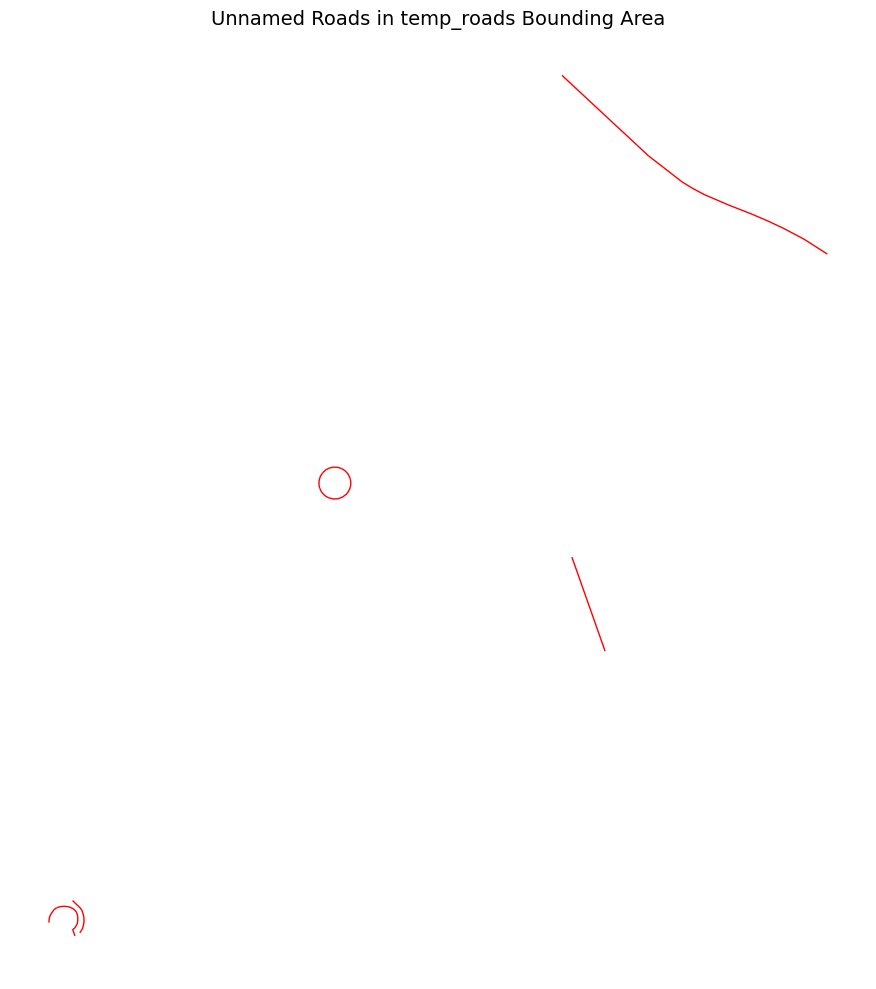

Total unnamed roads displayed: 13
    osm_id name    highway waterway aerialway barrier man_made railway  z_order                                                                                                                                                                                                                                                     other_tags speed_limit                                                                                                                                                                                                                                                                                                                                       geometry name_plot highway_plot
   6748290  NaN    service      NaN       NaN     NaN      NaN     NaN        0                                                                                                                                                                                      

In [39]:
# Visualize each highway type in horizontal subplot panels
roads_in_temp_area["highway_plot"] = (
    roads_in_temp_area["highway"].fillna("no_highway").astype(str).str.strip()
)
highway_types = sorted(h for h in roads_in_temp_area["highway_plot"].unique() if h != "")

if highway_types:
    n = len(highway_types)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes_flat = axes.ravel()

    for i, hwy in enumerate(highway_types):
        subset = roads_in_temp_area[roads_in_temp_area["highway_plot"] == hwy]
        subset.plot(ax=axes_flat[i], linewidth=1.0, color="steelblue")
        axes_flat[i].set_title(f"{hwy} (n={len(subset)})", fontsize=11)
        axes_flat[i].set_axis_off()

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("Roads by Highway Type", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize unnamed roads horizontally with context
unnamed_roads = roads_in_temp_area[
    roads_in_temp_area["name"].isna() | (roads_in_temp_area["name"].astype(str).str.strip() == "")
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

roads_in_temp_area.plot(ax=axes[0], linewidth=0.8, color="lightgray")
axes[0].set_title(f"All roads in temp area (n={len(roads_in_temp_area)})", fontsize=12)
axes[0].set_axis_off()

unnamed_roads.plot(ax=axes[1], linewidth=1.0, color="red")
axes[1].set_title(f"Unnamed roads (n={len(unnamed_roads)})", fontsize=12)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

print(f"Total unnamed roads displayed: {len(unnamed_roads)}")
print(unnamed_roads.to_string(index=False))
# Visualize each highway type in a different plot
roads_in_temp_area["highway_plot"] = (
    roads_in_temp_area["highway"].fillna("no_highway").astype(str).str.strip()
)
highway_types = sorted(h for h in roads_in_temp_area["highway_plot"].unique() if h != "")

for hwy in highway_types:
    subset = roads_in_temp_area[roads_in_temp_area["highway_plot"] == hwy]
    if subset.empty:
        continue

    fig, ax = plt.subplots(figsize=(8, 8))
    subset.plot(ax=ax, linewidth=1.0, color="steelblue")
    ax.set_title(f"Highway type: {hwy} (n={len(subset)})", fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# Visualize all roads without a name (within current temp area)
unnamed_roads = roads_in_temp_area[
    roads_in_temp_area["name"].isna() | (roads_in_temp_area["name"].astype(str).str.strip() == "")
].copy()

fig, ax = plt.subplots(figsize=(10, 10))
unnamed_roads.plot(ax=ax, linewidth=1.0, color="red")
ax.set_title("Unnamed Roads in temp_roads Bounding Area", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total unnamed roads displayed: {len(unnamed_roads)}")

# Full list of displayed data
print(unnamed_roads.to_string(index=False))


In [28]:
# display all seconddairy highway roads in roads_in_temp_area
secondary_roads = roads_in_temp_area[roads_in_temp_area['highway'] == 'secondary'].copy()

secondary_roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry,name_plot,highway_plot
19934,6748519,Nieuw-Eyckholt,secondary,NaN,NaN,NaN,NaN,NaN,6,"""bicycle""=>""use_sidepath"",""foot""=>""use_sidepat...",50,"LINESTRING (5.96742 50.8856, 5.96808 50.88605)",Nieuw-Eyckholt,secondary


In [29]:
# in roads_heerlen return all other_tags that contain junction roundabot, this is an example of this other_tags
# "bicycle"=>"use_sidepath","foot"=>"use_sidepath","junction"=>"roundabout","lanes"=>"1","lit"=>"yes","maxspeed"=>"50","mofa"=>"use_sidepath","roundabout"=>"turbo","surface"=>"asphalt","zone:traffic"=>"NL:urban"
roundabout_roads = roads_heerlen[roads_heerlen['other_tags'].str.contains('junction"=>"roundabout', na=False)].copy()
roundabout_roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
74388,198089648,NaN,tertiary,NaN,NaN,NaN,NaN,NaN,4,"""cycleway:right""=>""lane"",""cycleway:right:lane""...",50,"LINESTRING (5.96489 50.87488, 5.96492 50.87487..."


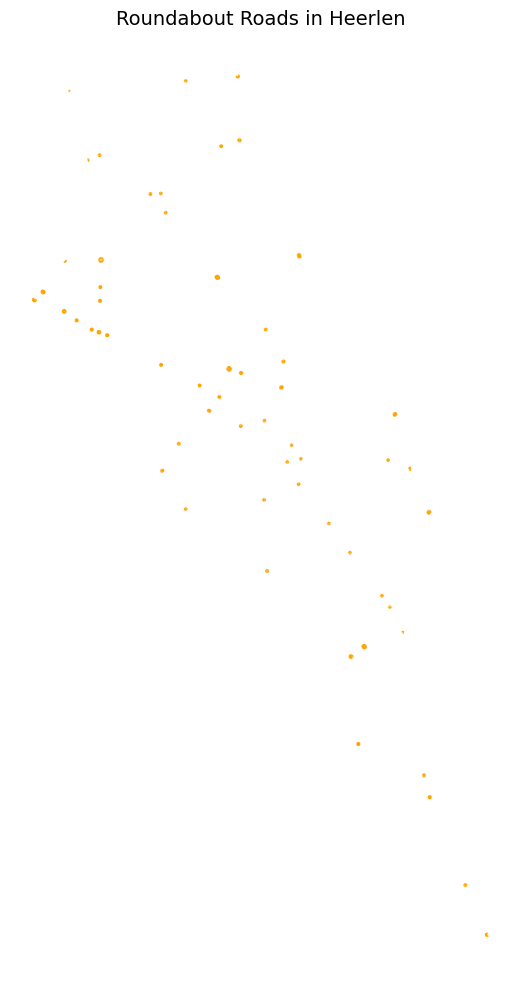

In [30]:
# display all roundabout roads in roads_heerlen
roundabout_roads = roads_heerlen[roads_heerlen['other_tags'].str.contains('junction"=>"roundabout', na=False)].copy()
roundabout_roads.plot(figsize=(10, 10), color="orange", linewidth=1.5)
plt.title("Roundabout Roads in Heerlen", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

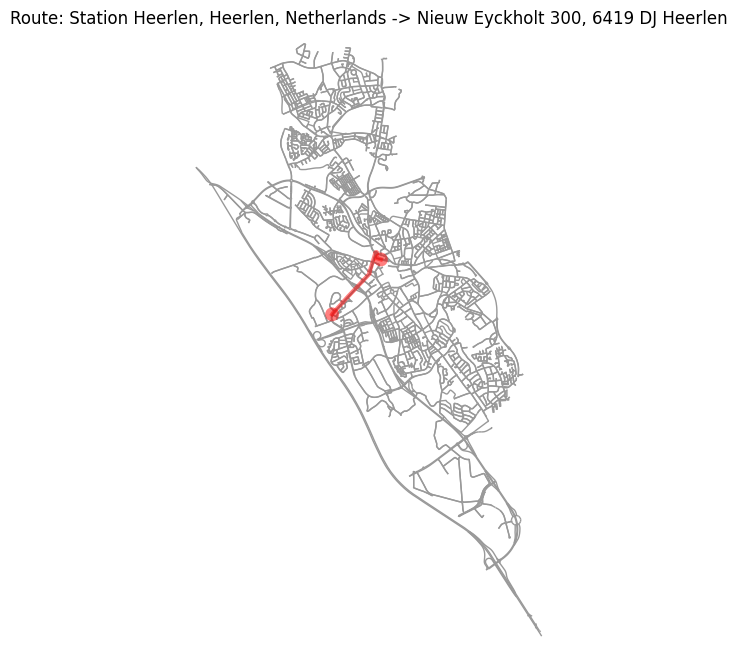

In [31]:
# Set your route endpoints here
start_point = "Station Heerlen, Heerlen, Netherlands"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

In [32]:
# Build edge-level connectivity + travel time tables from the routing graph
import numpy as np

# 1) Add speed and travel time attributes (travel_time in seconds)
route_graph_tt = ox.add_edge_speeds(route_graph)
route_graph_tt = ox.add_edge_travel_times(route_graph_tt)

# 2) Convert graph edges to a table
edges_gdf = ox.graph_to_gdfs(route_graph_tt, nodes=False, edges=True).reset_index()

# Keep common attributes if present
cols = ["u", "v", "key", "name", "highway", "length", "speed_kph", "travel_time", "geometry"]
edge_table = edges_gdf[[c for c in cols if c in edges_gdf.columns]].copy()

# Clean name/highway fields (they can be lists)
def _to_text(value):
    if isinstance(value, list):
        return " | ".join(map(str, value))
    return value

if "name" in edge_table.columns:
    edge_table["name"] = edge_table["name"].apply(_to_text)
if "highway" in edge_table.columns:
    edge_table["highway"] = edge_table["highway"].apply(_to_text)

# Add human-readable travel time
if "travel_time" in edge_table.columns:
    edge_table["travel_time_min"] = edge_table["travel_time"] / 60.0

print(f"Directed road segments (edges): {len(edge_table):,}")
edge_table.head(10)

# 4) Route-specific breakdown (only edges used by your shortest route)
route_pairs = list(zip(route[:-1], route[1:]))
route_rows = []
for u, v in route_pairs:
    edge_data = route_graph_tt.get_edge_data(u, v)
    if not edge_data:
        continue
    # choose the fastest parallel edge if multiple exist
    best_key, best_attrs = min(edge_data.items(), key=lambda kv: kv[1].get("travel_time", np.inf))
    route_rows.append({
        "u": u,
        "v": v,
        "key": best_key,
        "name": _to_text(best_attrs.get("name")),
        "highway": _to_text(best_attrs.get("highway")),
        "length_m": best_attrs.get("length"),
        "speed_kph": best_attrs.get("speed_kph"),
        "travel_time_s": best_attrs.get("travel_time"),
        "travel_time_min": (best_attrs.get("travel_time") / 60.0) if best_attrs.get("travel_time") is not None else None,
    })

route_breakdown = pd.DataFrame(route_rows)
print("Route segment breakdown:")
display(route_breakdown.head(20))

if not route_breakdown.empty:
    total_len_km = route_breakdown["length_m"].sum() / 1000.0
    total_time_min = route_breakdown["travel_time_min"].sum()
    print(f"Total route length: {total_len_km:.2f} km")
    print(f"Estimated route time: {total_time_min:.1f} minutes")

# Optional exports for external use
edge_table.to_csv("../output/heerlen_edge_table.csv", index=False)

Directed road segments (edges): 6,824
Route segment breakdown:


,u,v,key,name,highway,length_m,speed_kph,travel_time_s,travel_time_min
0,1529791500,6742883936,0,Melkweg,busway,154.761783,15.0,37.142828,0.619047
1,6742883936,1529791529,0,Melkweg,busway,7.548923,50.0,0.543522,0.009059
2,1529791529,1529791591,0,Melkweg,busway,10.922278,50.0,0.786404,0.013107
3,1529791591,597499342,0,Melkweg,busway,15.829936,50.0,1.139755,0.018996
4,597499342,6742883970,0,NaN,busway,8.030671,50.0,0.578208,0.009637
5,6742883970,6742872252,0,NaN,secondary,14.802078,50.0,1.065750,0.017762
6,6742872252,6742872279,0,NaN,secondary,46.570519,50.0,3.353077,0.055885
7,6742872279,453163380,0,NaN,secondary,15.958472,50.0,1.149010,0.019150
8,453163380,6742883984,0,NaN,secondary,10.368133,50.0,0.746506,0.012442
9,6742883984,1927699986,0,Looierstraat,secondary,333.487378,50.0,24.011091,0.400185


Total route length: 1.90 km
Estimated route time: 2.7 minutes


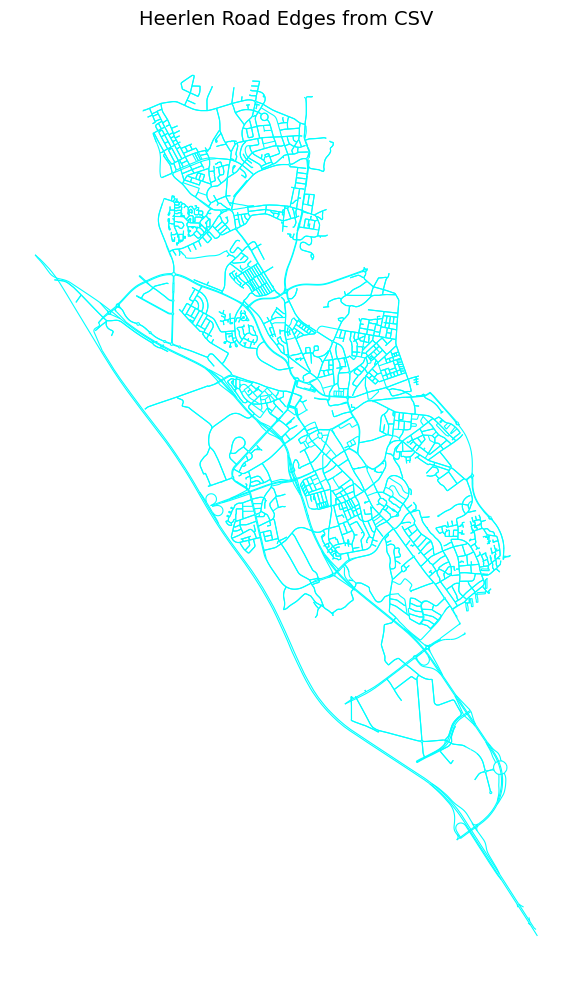

In [33]:
# plot all the edges from ../output/heerlen_edge_table.csv
edges_df = pd.read_csv("../output/heerlen_edge_table.csv")
edges_gdf = gpd.GeoDataFrame(
    edges_df,
    geometry=gpd.GeoSeries.from_wkt(edges_df["geometry"]),
    crs="EPSG:4326"
)
edges_gdf = edges_gdf.to_crs(epsg=3857)
edges_gdf.plot(figsize=(10, 10), color="cyan", linewidth=0.8)
plt.title("Heerlen Road Edges from CSV", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


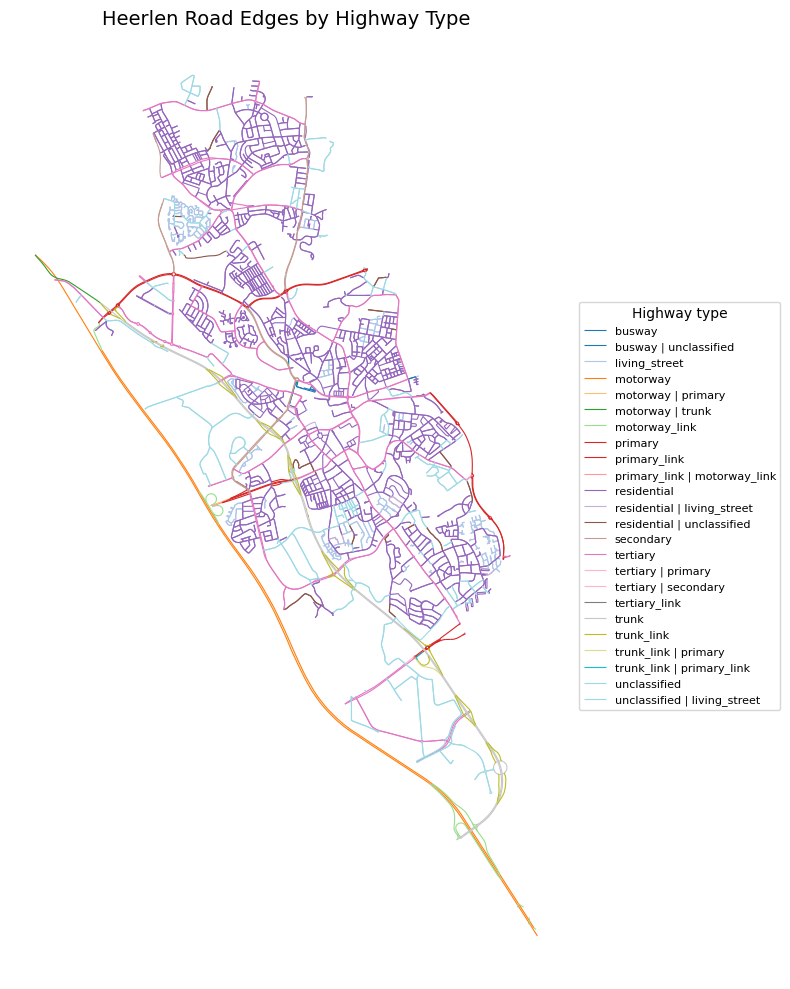

In [34]:
# Plot with one colour per highway type, including missing values as "unknown"
segments = edges_gdf.copy()

if segments.crs is None or segments.crs.to_epsg() != 3857:
    segments = segments.to_crs(epsg=3857)

segments["highway_plot"] = segments["highway"].fillna("unknown").astype(str).str.strip()
segments.loc[segments["highway_plot"] == "", "highway_plot"] = "unknown"

highway_types = sorted(segments["highway_plot"].unique())
cmap = plt.get_cmap("tab20", max(len(highway_types), 1))

fig, ax = plt.subplots(figsize=(10, 10))
for i, hwy in enumerate(highway_types):
    segments[segments["highway_plot"] == hwy].plot(
        ax=ax,
        color=cmap(i),
        linewidth=0.8,
        label=hwy
    )

ax.set_title("Heerlen Road Edges by Highway Type", fontsize=14)
ax.set_axis_off()
ax.legend(title="Highway type", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


In [42]:
from pathlib import Path

import geopandas as gpd

# Find the PBF file from common relative locations
candidate_paths = [
    Path("limburg-260312.osm.pbf"),
    Path("../limburg-260312.osm.pbf"),
]
pbf_path = next((p for p in candidate_paths if p.exists()), None)
if pbf_path is None:
    raise FileNotFoundError("Could not find limburg-260312.osm.pbf in current or parent folder.")

# List layers using pyogrio if available, otherwise fiona
layers = []
try:
    import pyogrio

    layer_info = pyogrio.list_layers(pbf_path)
    layers = [name for name, _geom in layer_info]
    print("Layers found (pyogrio):")
    for name, geom in layer_info:
        print(f"- {name} (geometry: {geom})")
except Exception as e:
    print(f"pyogrio not available or failed ({e}); trying fiona...")
    import fiona

    layers = fiona.listlayers(pbf_path)
    print("Layers found (fiona):")
    for name in layers:
        print(f"- {name}")

if not layers:
    raise ValueError("No layers found in the PBF file.")



Layers found (pyogrio):
- points (geometry: Point)
- lines (geometry: LineString)
- multilinestrings (geometry: MultiLineString)
- multipolygons (geometry: MultiPolygon)
- other_relations (geometry: GeometryCollection)


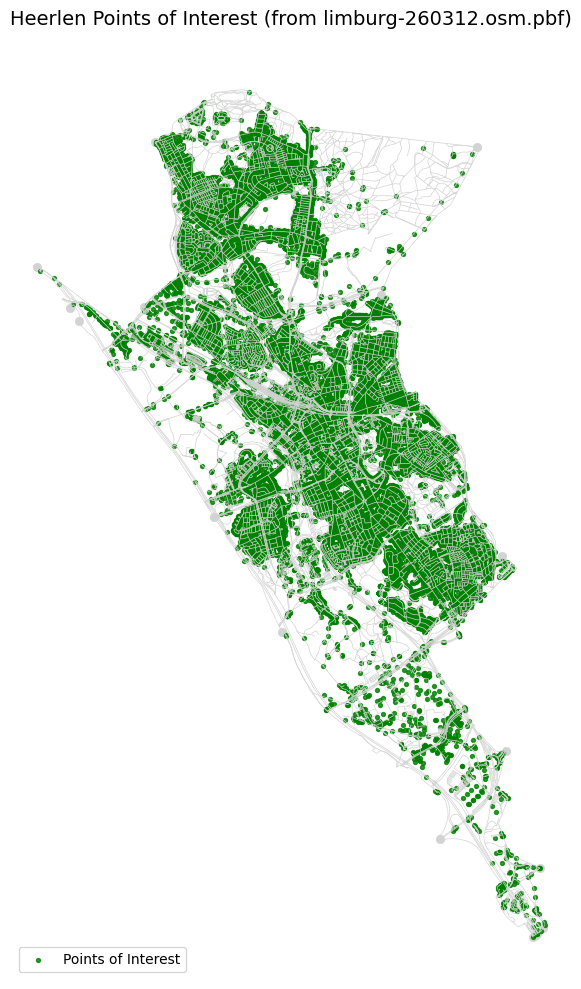

Total points in PBF: 794272
Points within Heerlen: 48119
Sample points data:


,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
754620,11841858741,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,"""addr:city""=>""Heerlen"",""addr:housenumber""=>""30...",POINT (664447.094 6597971.849)


In [ ]:
# Load points and filter to Heerlen only
points = gpd.read_file(pbf_path, layer="points")
points = points.to_crs(epsg=3857)

# Get Heerlen boundary and clip points to it
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(points.crs)
points_heerlen = gpd.clip(points, heerlen_boundary.geometry.iloc[0])

# Also clip roads to Heerlen for context
roads = gpd.read_file(pbf_path, layer="lines")
roads = roads.to_crs(epsg=3857)
roads_heerlen = gpd.clip(roads, heerlen_boundary.geometry.iloc[0])

# Plot together
fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="lightgray")
points_heerlen.plot(ax=ax, color="green", markersize=8, alpha=0.8, label="Points of Interest")

ax.set_title("Heerlen Points (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Total points in PBF: {len(points)}")
print(f"Points within Heerlen: {len(points_heerlen)}")

# Head the pandas DataFrame of points to see available attributes
print("Sample points data:")
points_heerlen.head(1)

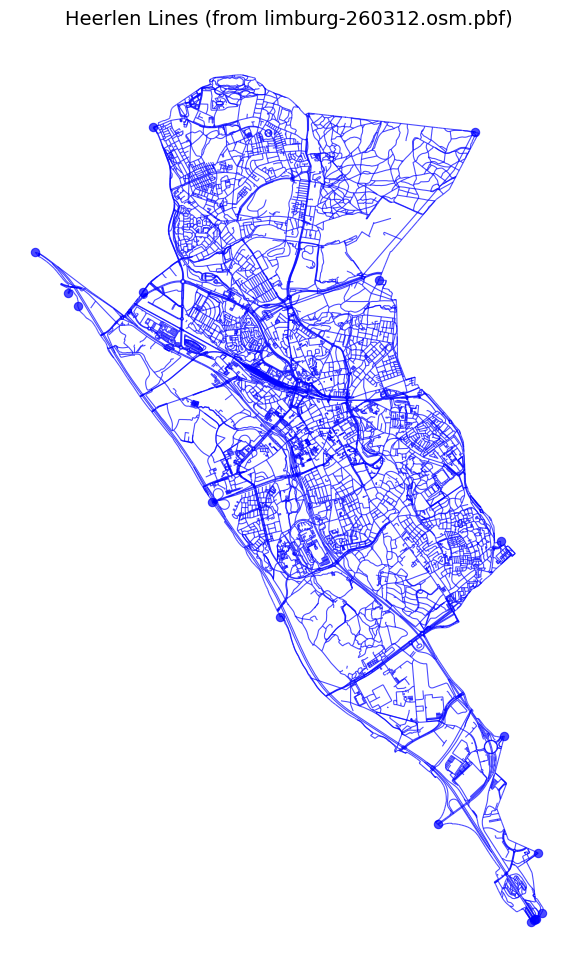

Total lines in PBF: 238605
Lines within Heerlen: 11694
Sample lines data:


,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,geometry
55589,115300245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"""cables""=>""6"",""circuits""=>""2"",""frequency""=>""50...","MULTILINESTRING ((669371.925 6597417.304, 6692..."


In [64]:
# Load and plot Lines layer (LineString) filtered to Heerlen
lines = gpd.read_file(pbf_path, layer="lines")
lines = lines.to_crs(epsg=3857)
lines_heerlen = gpd.clip(lines, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
lines_heerlen.plot(ax=ax, linewidth=0.8, color="blue", alpha=0.7)
ax.set_title("Heerlen Lines (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total lines in PBF: {len(lines)}")
print(f"Lines within Heerlen: {len(lines_heerlen)}")

# Head the pandas DataFrame of lines to see available attributes
print("Sample lines data:")
lines_heerlen.head(1)


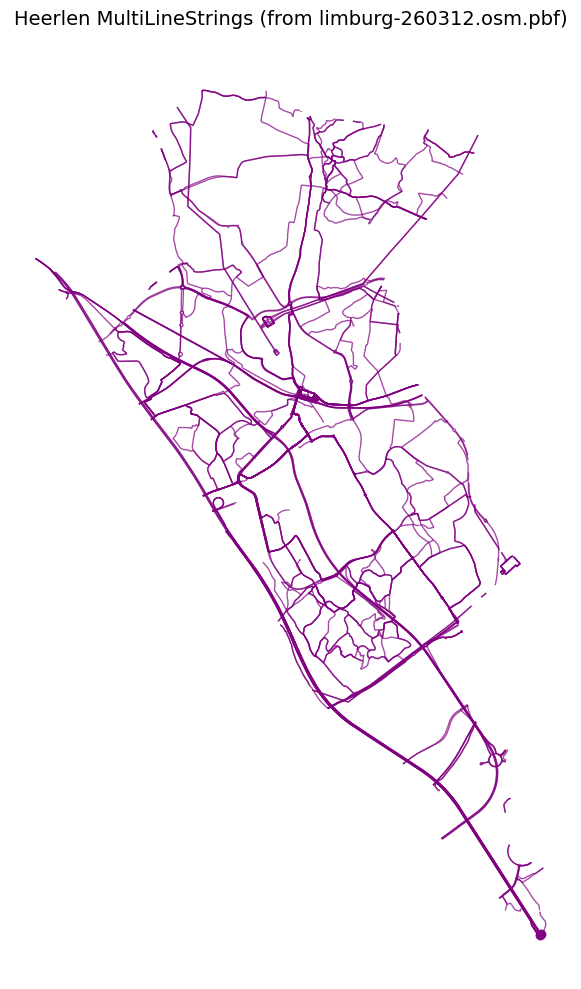

Total multilinestrings in PBF: 9151
MultiLineStrings within Heerlen: 219
Sample multilinestrings data:


,osm_id,name,type,other_tags,geometry
7351,11561250,"Flixbus 328: Lille, Boulevard de Turin => Fran...",route,"""from""=>""Lille, Boulevard de Turin"",""headway""=...","MULTILINESTRING ((663181.505 6598894.505, 6632..."


In [65]:
# Load and plot MultiLineStrings layer (MultiLineString) filtered to Heerlen
multilinestrings = gpd.read_file(pbf_path, layer="multilinestrings")
multilinestrings = multilinestrings.to_crs(epsg=3857)
multilinestrings_heerlen = gpd.clip(multilinestrings, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
multilinestrings_heerlen.plot(ax=ax, linewidth=1.0, color="purple", alpha=0.7)
ax.set_title("Heerlen MultiLineStrings (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total multilinestrings in PBF: {len(multilinestrings)}")
print(f"MultiLineStrings within Heerlen: {len(multilinestrings_heerlen)}")

# Head the pandas DataFrame of multilinestrings to see available attributes
print("Sample multilinestrings data:")
multilinestrings_heerlen.head(1)


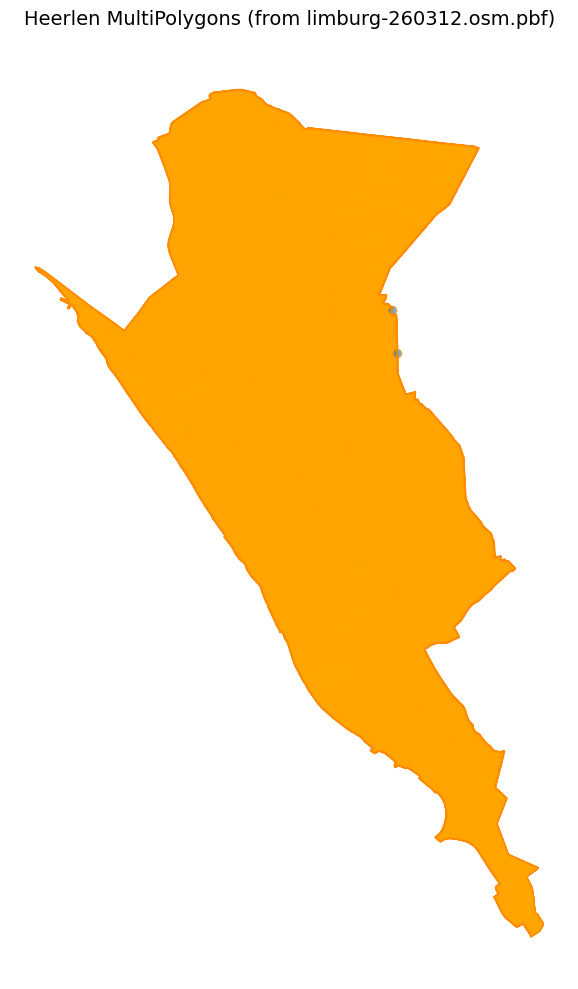

Total multipolygons in PBF: 1046551
MultiPolygons within Heerlen: 48460
Sample multipolygons data:


,osm_id,osm_way_id,name,type,aeroway,amenity,admin_level,barrier,boundary,building,...,man_made,military,natural,office,place,shop,sport,tourism,other_tags,geometry
2700,2721306,NaN,Bocholtz,boundary,NaN,NaN,10,NaN,administrative,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""authoritative""=>""yes"",""ref:woonplaatscode""=>""...","MULTILINESTRING ((670557.777 6589233.698, 6705..."


In [66]:
# Load and plot MultiPolygons layer (MultiPolygon) filtered to Heerlen
multipolygons = gpd.read_file(pbf_path, layer="multipolygons")
multipolygons = multipolygons.to_crs(epsg=3857)
multipolygons_heerlen = gpd.clip(multipolygons, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
multipolygons_heerlen.plot(ax=ax, facecolor="orange", edgecolor="darkorange", alpha=0.6)
ax.set_title("Heerlen MultiPolygons (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total multipolygons in PBF: {len(multipolygons)}")
print(f"MultiPolygons within Heerlen: {len(multipolygons_heerlen)}")

# Head the pandas DataFrame of multipolygons to see available attributes
print("Sample multipolygons data:")
multipolygons_heerlen.head(1)

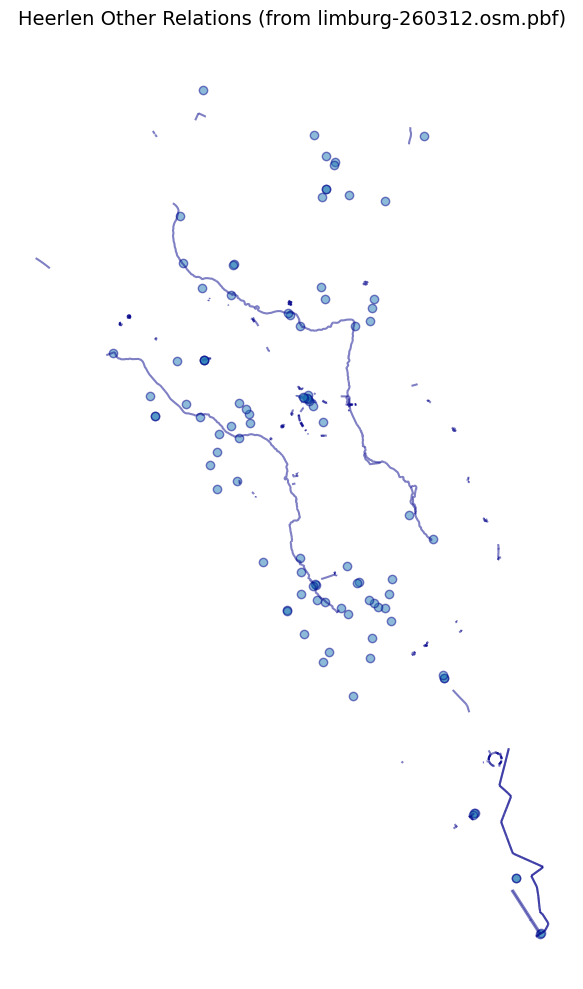

Total other_relations in PBF: 1766
Other relations within Heerlen: 194
Sample other_relations data:


,osm_id,name,type,other_tags,geometry
1285,16115548,NaN,restriction,"""restriction""=>""only_straight_on""","MULTILINESTRING ((660652.023 6603761.214, 6606..."


In [67]:
# Load and plot Other Relations layer (GeometryCollection) filtered to Heerlen
other_relations = gpd.read_file(pbf_path, layer="other_relations")
other_relations = other_relations.to_crs(epsg=3857)
other_relations_heerlen = gpd.clip(other_relations, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
other_relations_heerlen.plot(ax=ax, facecolor="cyan", edgecolor="darkblue", alpha=0.5)
ax.set_title("Heerlen Other Relations (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total other_relations in PBF: {len(other_relations)}")
print(f"Other relations within Heerlen: {len(other_relations_heerlen)}")

# Head the pandas DataFrame of other_relations to see available attributes
print("Sample other_relations data:")
other_relations_heerlen.head(1)

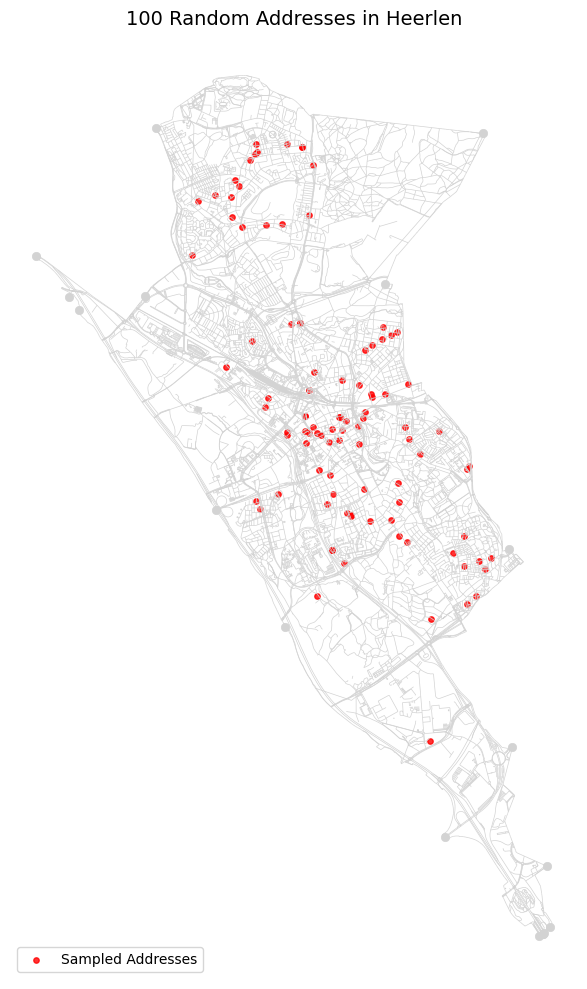

Saved 100 addresses to ../output/heerlen_addresses.csv
                 street housenumber postcode     city  \
0            Tempsplein          13   6411ES  Heerlen   
1        Gasthuisstraat          47   6416AM  Heerlen   
2            Kampstraat         124   6413EG  Heerlen   
3           Ammonieterf         293   6413KT  Heerlen   
4       Donderdagstraat      9-GB38      NaN  Heerlen   
5              Putgraaf           5   6411GT  Heerlen   
6          Gravenstraat          28   6413ES  Heerlen   
7      Frans Halsstraat           6   6415TH  Heerlen   
8         K.L.M.-straat           3   6417AW  Heerlen   
9  Titus Brandsmastraat          25   6414BK  Heerlen   

                              full_address  
0            Tempsplein 13, 6411ES Heerlen  
1        Gasthuisstraat 47, 6416AM Heerlen  
2           Kampstraat 124, 6413EG Heerlen  
3          Ammonieterf 293, 6413KT Heerlen  
4         Donderdagstraat 9-GB38,  Heerlen  
5               Putgraaf 5, 6411GT Heerlen  
6 

In [ ]:
# Load PBF file and extract necessary data for address extraction

# Find the PBF file
candidate_paths = [
    Path("limburg-260312.osm.pbf"),
    Path("../limburg-260312.osm.pbf"),
]
pbf_path = next((p for p in candidate_paths if p.exists()), None)
if pbf_path is None:
    raise FileNotFoundError("Could not find limburg-260312.osm.pbf in current or parent folder.")

# Load points and roads for Heerlen
points = gpd.read_file(pbf_path, layer="points")
points = points.to_crs(epsg=3857)

heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(points.crs)
points_heerlen = gpd.clip(points, heerlen_boundary.geometry.iloc[0])

roads = gpd.read_file(pbf_path, layer="lines")
roads = roads.to_crs(epsg=3857)
roads_heerlen = gpd.clip(roads, heerlen_boundary.geometry.iloc[0])

import re
from pathlib import Path
import geopandas as gpd
import osmnx as ox

points_with_addr = points_heerlen[points_heerlen['other_tags'].notna() & points_heerlen['other_tags'].str.contains('addr:', na=False)].copy()


# Extract address information from points' other_tags and sample 100 random addresses within Heerlen

# Sample 100 random points from points_heerlen
sample_points = points_with_addr.sample(n=min(100, len(points_with_addr)), random_state=42).copy()

# Extract address components from other_tags
def extract_address_info(other_tags):
    if pd.isna(other_tags):
        return {}
    
    info = {}
    # Extract common address fields
    patterns = {
        'street': r'"addr:street"=>"([^"]+)"',
        'housenumber': r'"addr:housenumber"=>"([^"]+)"',
        'postcode': r'"addr:postcode"=>"([^"]+)"',
        'city': r'"addr:city"=>"([^"]+)"',
    }
    
    for key, pattern in patterns.items():
        match = re.search(pattern, other_tags)
        info[key] = match.group(1) if match else None
    
    return info

# Apply extraction
address_data = sample_points['other_tags'].apply(extract_address_info)
address_df = pd.DataFrame(list(address_data))

# Combine with geometry
sample_points_with_addr = pd.concat([
    sample_points[['geometry']].reset_index(drop=True),
    address_df
], axis=1)

# Create full address string
sample_points_with_addr['full_address'] = (
    sample_points_with_addr['street'].fillna('') + ' ' +
    sample_points_with_addr['housenumber'].fillna('') + ', ' +
    sample_points_with_addr['postcode'].fillna('') + ' ' +
    sample_points_with_addr['city'].fillna('')
).str.strip()

# Save to CSV
output_addresses = sample_points_with_addr[['street', 'housenumber', 'postcode', 'city', 'full_address']].copy()
output_addresses.to_csv("../output/heerlen_addresses.csv", index=False)

# Plot on roads
fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="lightgray")
sample_points_with_addr.plot(ax=ax, color="red", markersize=15, alpha=0.8, label="Sampled Addresses")

ax.set_title(f"100 Random Addresses in Heerlen", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Saved {len(output_addresses)} addresses to ../output/heerlen_addresses.csv")
print(output_addresses.head(10))
